# 6.3-6.5 TD法(後半)

In [ ]:
# import
if '__file__' in globals():
    import os, sys
    sys.path.append(os.path.join(os.path.dirname(__file__), '..'))
from collections import defaultdict, deque
import numpy as np
from common.gridworld import GridWorld
from common.utils import greedy_probs

## 6.3 方策オフ型のSARSA
前節: 方策オン型のSARSA  
**本節: 方策オフ型のSARSA**

> 方策オン型(on-policy): 自分で得た経験から自分の方策を改善  
> 方策オフ型(off-policy): 自分とは別の場所で得られた経験から自分の方策を改善

### 6.3.1 方策オフ型と重点サンプリング
方策オフ: 挙動方策とターゲット方策が異なる  
　挙動方策で、多様な行動を行って広くサンプルデータを集める  
　→そのサンプルデータを使って、ターゲット方策をgreedyに更新

> 注意点
> * 挙動方策とターゲット方策は似たような確率分布である方が安定する  
>   その点を考慮して、現状のQ関数に対して挙動方策は $\varepsilon$-greedyに更新し、  
>   ターゲット方策はgreedyに更新
> * 2つの方策が異なるため、重点サンプリングを使って重み $\rho$ による補正を行う

例）
$Q_\pi (S_t, A_t)$ を更新する場合を考える。このとき、SARSAの更新式は次のようになる。

$\displaystyle \hspace{10mm}
Q_\pi ' (S_t, A_t) = Q_\pi (S_t, A_t) + \alpha \{R_t + \gamma Q_\pi (S_{t+1}, A_{t+1}) - Q_\pi(S_t, A_t) \}
\hspace{10mm} (6.10)
$

また、この更新式に対応するバックアップ線図は次のようになる。

<img src="img/fig6-8.jpg" width=700>

図6-8で示すように、ペアデータ $(S_t, A_t)$ が更新対象。  
この更新対象は任意に選ぶことができ、選んだペアデータに対して次の時刻$t+1$の遷移を考える。  
> 次の状態 $S_{t+1}$ は、環境の状態遷移確率 $p(s'|s,a)$ によってサンプリングされる。  
> $\hspace{50mm} \displaystyle\downarrow$   
> 状態 $S_{t+1}$ で選ばれる行動 $A_{t+1}$ は、ターゲット方策 $\pi$ (もしくは挙動方策 $b$ )によってサンプリングされる。

方策 $\pi$ によって行動が選ばれることを明示すると、SARSAの更新式は次のように書ける。

$\displaystyle \hspace{10mm}
\mathrm{sampling : }A_{t+1} \sim \pi \\\hspace{10mm}
Q_\pi ' (S_t, A_t) = Q_\pi (S_t, A_t) + \alpha \{R_t + \gamma Q_\pi (S_{t+1}, A_{t+1}) - Q_\pi(S_t, A_t) \}
\hspace{10mm} (6.12)
$

式(6.12)は、$Q_\pi (S_t, A_t)$ を $R_t + \gamma Q_\pi (S_{t+1}, A_{t+1})$ の方向へ更新することを表している。  
この $R_t + \gamma Q_\pi (S_{t+1}, A_{t+1})$ は「TDターゲット」と呼ばれる。

行動 $A_{t+1}$ が方策 $b$ によってサンプリングされた場合、重み $\rho$ によってTDターゲットを補正する(=重点サンプリング)。  
重み $\rho$ は、「方策が $\pi$ だったときにTDターゲットが得られる確率」と「方策が $b$ だったときにTDターゲットが得られる確率」の比率で、

$\displaystyle \hspace{10mm}
\rho = \frac{\pi(A_{t+1}|S_{t+1})}{b(A_{t+1}|S_{t+1})}
$

よって、方策オフ型のSARSAの更新式は次の式で表される。

$\displaystyle \hspace{10mm}
\mathrm{sampling : }A_{t+1} \sim b \\\hspace{10mm}
Q_\pi ' (S_t, A_t) = Q_\pi (S_t, A_t) + \alpha \left\{ \rho \left( R_t + \gamma Q_\pi (S_{t+1}, A_{t+1})\right) - Q_\pi(S_t, A_t) \right\}
\hspace{10mm} (6.13)
$

### 6.3.2 方策オフ型のSARSAの実装

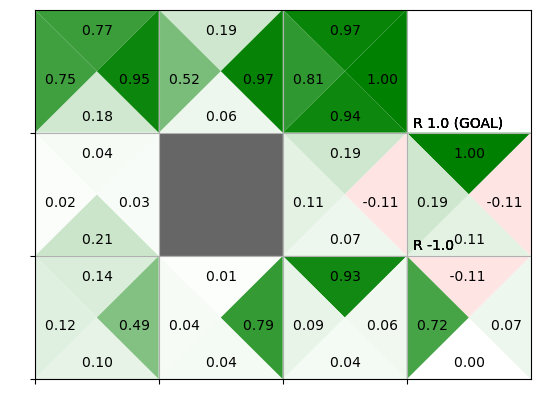

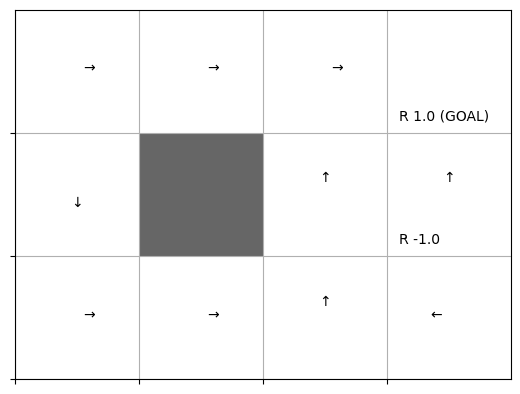

In [ ]:
class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state] # 1. 挙動方策から取得
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            # 2. 重みrhoを計算
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]

        # 3. rhoによるTDターゲットの補正
        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha
        #4. それぞれの方策を改善
        self.pi[state] = greedy_probs(self.Q, state, 0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

> まだ改善の余地はありそう

## 6.4 Q学習

方策オフ型のSARSAの問題点
* 重点サンプリングを使うため、結果が不安定になりやすい

これを解決するのが **Q学習 (Q-lerning)**

Q学習の特徴
* TD法
* 方策オフ型
* 重点サンプリングを使わない

SARSAとQ学習の導出の流れ  
　　ベルマン方程式 　　$\longrightarrow $　 SARSA  
　ベルマン最適方程式 　$\longrightarrow $　  Q学習

### 6.4.1 ベルマン方程式とSARSA

ベルマン方程式とSARSAの関係性を見る

<img src="img/fig6-11.jpg" width=700>

ベルマン方程式は、次の状態と次の行動のすべての候補を考慮する。  
それを踏まえたうえでSARSAを見ると、SARSAはベルマン方程式の「サンプリング版」と見なすことができる。  
(ここでの「サンプリング版」: すべての遷移ではなく、ある１つのサンプリングされたデータを使う)

<img src="img/fig6-12.jpg" width=700>

ベルマン方程式がSARSAに対応するのであれば、ベルマン**最適**方程式に対応するものも考えられる。
→それがQ学習！

### 6.4.2 ベルマン最適方程式とQ学習
「4.5 価値反復法」では、価値反復法は、最適方策を得るための  
「評価」と「改善」という2つのプロセスを1つにまとめた手法であることを学んだ。
* 価値反復法では、ベルマン最適方程式に基づくただ1つの更新式を繰り返すことで、最適方策が得られる  
→ベルマン最適方程式による更新で、それを「サンプリング版」にした手法について考える。

<img src="img/fig6-13.jpg" width=700>

図6-13を「サンプリング版」へ置き換えると、

<img src="img/fig6-14.jpg" width=700>

図6-14に基づく手法がQ学習。Q学習では、推定値 $Q(S_t,A_t)$ のターゲットは、  
 $R_t+\gamma \mathrm{max}_aQ(S_{t+1},a)$になる。更新式は、

$\displaystyle \hspace{10mm}
Q_\pi ' (S_t, A_t) = Q_\pi (S_t, A_t) + \alpha \{R_t + \gamma \mathrm{max}_a Q (S_{t+1}, a) - Q_\pi(S_t, A_t) \}
\hspace{10mm} (6.14)
$

式(6.14)に基づきQ関数を繰り返し更新することで、**最適方策**におけるQ関数へと近づく。

図6-14で重要な点は、行動 $A_{t+1}$ がQ関数の最大値によって選ばれていること  
(方策によるサンプリングではない)

### 6.4.3 Q学習の実装

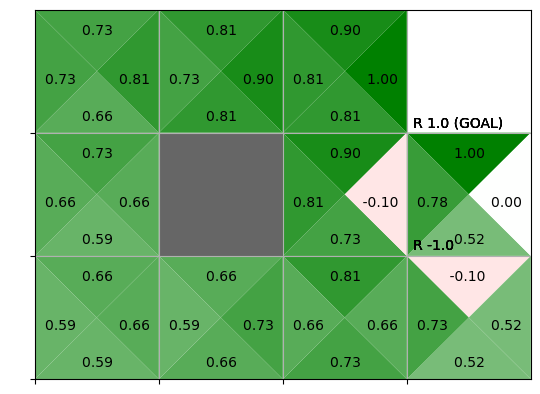

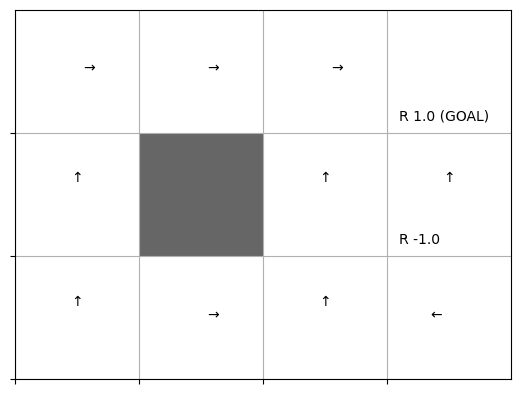

In [4]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)